# PROJET STOCK MARKET - PREDICTION DE EARNINGS

## Partie 1

Dans ce projet, l'objectif est de prédire la variable "earnings" du mois suivant à partir de plusieurs variables financières issues de la table standardandpoor.

In [594]:

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mysql.connector
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from data_windowing import WindowGenerator


# Parametres

In [595]:

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

INPUT_WIDTH = 5
LABEL_WIDTH = 1
SHIFT = 1

P_VAL = 0.1
P_TEST = 0.1

EPOCHS = 40
BATCH_SIZE = 12

FIGSIZE = (12, 6)

print("Paramètres chargés.")
print("Seed utilisée :", SEED)

Paramètres chargés.
Seed utilisée : 42


Cette partie du code permet de définir les paramètres généraux utilisés dans le projet. On fixe notamment une graine aléatoire (« seed »), ce qui permet de rendre les résultats reproductibles : si l’on exécute le programme plusieurs fois, on obtient les mêmes résultats. Le code définit également plusieurs hyperparamètres. Un hyperparamètre est un paramètre choisi par le programmeur avant l’entraînement du modèle, qui sert à contrôler le fonctionnement de l’algorithme. Par exemple, on définit ici la taille des fenêtres temporelles utilisées comme entrée du modèle, la proportion des données utilisées pour la validation et le test, le nombre d’époques (c’est-à-dire le nombre de fois que le modèle parcourt l’ensemble des données d’entraînement) ainsi que la taille des lots de données utilisés pendant l’apprentissage. Cette étape est importante car elle organise le cadre de l’expérience et garantit que les modèles seront entraînés de manière cohérente et comparable.


# Connexion a la base de donnees

In [596]:
config = {
    "user": "root",
    "password": "root",
    "host": "localhost",
    "database": "sdd4",
    "raise_on_warnings": True
}

bdd = mysql.connector.connect(**config)


# Importation des donnees 

In [597]:

def import_financialbehavior_table(bdd)->pd.DataFrame:
    cursor = bdd.cursor()
    cursor.execute("SELECT * FROM financial_behavior")
    columns = [col[0] for col in cursor.description]
    df = pd.DataFrame(cursor.fetchall(),columns = columns)
    df = df.set_index("idTB")

    return df 

def import_tweets_table(bdd) -> pd.DataFrame: 
    cursor = bdd.cursor()
    cursor.execute("SELECT * FROM tweets")
    columns = [col[0] for col in cursor.description]
    df = pd.DataFrame(cursor.fetchall(),columns = columns)
    df["observation_date"] = pd.to_datetime(df["observation_date"])
    df = df.set_index("idT")

    return df 

def import_bigmacindex_table(bdd) -> pd.DataFrame: 
    cursor = bdd.cursor()
    cursor.execute("SELECT * FROM bigmacindex")
    columns = [col[0] for col in cursor.description]
    df = pd.DataFrame(cursor.fetchall(),columns = columns)
    df["observation_date"] = pd.to_datetime(df["observation_date"])
    for columns in df.columns: 
        if columns != "observation_date": 
            df[columns] = df[columns].astype(float)
    df = df.set_index("idBM")

    return df 

def import_bitcoinperformance_table(bdd) ->pd.DataFrame: 
    cursor = bdd.cursor()
    cursor.execute("SELECT * FROM bitcoinperformance")
    columns = [col[0] for col in cursor.description]
    df = pd.DataFrame(cursor.fetchall(),columns = columns)
    df["observation_date"] = pd.to_datetime(df["observation_date"])
    for columns in df.columns: 
        if columns != "observation_date": 
            df[columns] = df[columns].astype(float)
    df = df.set_index("idB")

    return df 

def import_sp500_table(bdd)->pd.DataFrame:
    cursor = bdd.cursor()
    cursor.execute("SELECT * FROM standardandpoor")
    columns = [col[0] for col in cursor.description]
    df = pd.DataFrame(cursor.fetchall(),columns = columns)
    df["observation_date"] = pd.to_datetime(df["observation_date"])
    df = df.rename(columns={"observation_date": "date"})
    df = df.set_index("idSP")

    return df

def import_inflation_table(bdd) ->pd.DataFrame:

    cursor = bdd.cursor()
    cursor = bdd.cursor()
    cursor.execute("SELECT * FROM inflation")
    columns = [col[0] for col in cursor.description]
    df = pd.DataFrame(cursor.fetchall(),columns=columns)
    df = df.rean
    df["observation_date"] = pd.to_datetime(df["observation_date"])
    df["CPI"] = df["CPI"].astype(float)
    df = df.set_index("idI")

    return df

def import_joinTable(bdd,*args:pd.DataFrame): 
    df = import_sp500_table(bdd)
    for table in args: 
        df = df.merge(table,on = "observation_date",how = "inner")

    
    return df

def standar_df(df:pd.DataFrame): 
    for columns in df.columns: 
        df[columns] = (df[columns] - df[columns].mean())/df[columns].std()
    
    return df



In [598]:
df = import_sp500_table(bdd)
sp = standar_df(df.copy())


MEAN_EARNINGS = df["earnings"].mean()
STD_EARNINGS = df["earnings"].std()

In [599]:


target_col = "earnings"

features = [
    "sp500",
    "dividend",
    "earnings",
    "longInterestRate"
]

df_model = sp[features].copy()

df_model




,sp500,dividend,earnings,longInterestRate
idSP,,,,
2,-0.461055,-0.528404,-0.496333,0.367589
3,-0.461074,-0.528404,-0.496333,0.361070
4,-0.460938,-0.528404,-0.496333,0.365416
5,-0.460777,-0.528404,-0.496333,0.365416
6,-0.460629,-0.528404,-0.496333,0.365416
...,...,...,...,...
1830,4.658198,4.392132,4.579796,-0.399512
1831,4.904417,4.404383,4.636586,-0.321281
1832,5.105533,4.404383,4.636586,-0.256088


# class WindowGenerator 

In [600]:
target_index = df_model.columns.get_loc(target_col)

wg_lstm = WindowGenerator(
    df=df_model,
    input_width=INPUT_WIDTH,
    shift=SHIFT,
    p_val_df=P_VAL,
    p_test_df=P_TEST,
    label_width=LABEL_WIDTH,
    label_encoder= target_index
)

wg_linear = WindowGenerator(
    df=df_model,
    input_width=1,
    shift=1,
    p_val_df=P_VAL,
    p_test_df=P_TEST,
    label_width=1,
    label_encoder= target_index
)

wg_linear_uni_variable = WindowGenerator(
    df=df_model["earnings"],
    input_width=1,
    shift=1,
    p_val_df=P_VAL,
    p_test_df=P_TEST,
    label_width=1,
)

# Prediction

### Baseline

In [601]:


class BaselinePredictor:

    def __init__(self, shift: int = 1, target_index: int = 0):
        self.shift = shift
        self.target_index = target_index

    def fit(self, X: np.ndarray, y: np.ndarray):
        
        self.X_train_ = X
        self.y_train_ = y
    
        if self.shift == 1:
            y_pred = X[-1,self.target_index]
        else:
            y_pred = X[-self.shift, self.target_index]

        y_pred = y_pred.reshape(-1)
        y_true = y.flatten()

        loss = np.mean((y_true - y_pred) ** 2)
        mae = np.mean(np.abs(y_true - y_pred))

        self.history = {'loss': loss, 'mae': mae}

        return self.history


    def predict(self, X: np.ndarray) -> np.ndarray:
        if self.shift == 1:
            y_pred = X[-1, self.target_index]
        else:
            y_pred = X[-self.shift, self.target_index]

 
        return y_pred
        






# Modeles 

In [ ]:

def build_linear_model(input_shape):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.Dense(1)
    ])

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )
    return model


def build_dense_model(input_shape):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(1)
    ])

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )
    return model


def build_lstm_model(input_shape):
        
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.LSTM(32, activation='tanh',return_sequences=True),  
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.LSTM(32, activation='tanh'), 
        tf.keras.layers.Dropout(0.2), 

        tf.keras.layers.Dense(1)             
    ])

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )
    return model

    
def plot_prediction(wg: WindowGenerator, model: tf.keras.Sequential,
                    mean: float = MEAN_EARNINGS, std: float = STD_EARNINGS):

    plt.figure(figsize=FIGSIZE)
 
    y_pred = model.predict(wg.training_input).flatten()
    y_pred = (y_pred + mean) * std  

   
    y_real = wg.training_label.flatten()
    y_real = (y_real + mean) * std  

    plt.plot(y_pred, label="Predicted")
    plt.plot(y_real, label="Real")
    plt.legend()
    plt.show()

def plot_prediction_test(wg: WindowGenerator, model: tf.keras.Sequential,
                    mean: float = MEAN_EARNINGS, std: float = STD_EARNINGS):

    plt.figure(figsize=FIGSIZE)
 
    y_pred = model.predict(wg.test_input).flatten()
    y_pred = (y_pred + mean) * std  

   
    y_real = wg.test_label.flatten()
    y_real = (y_real + mean) * std  

    plt.plot(y_pred, label="Predicted")
    plt.plot(y_real, label="Real")
    plt.legend()
    plt.show()

def plot_prediction_test_general(wg: WindowGenerator, model: tf.keras.Sequential,label_encoder:int = None,
                    mean: float = MEAN_EARNINGS, std: float = STD_EARNINGS):
    
    if label_encoder is not None:
        x,y = wg.split(wg.raw_df.to_numpy(),wg.input_width,wg.shift,wg.label_width,2)
    else:
        x,y = wg.split(wg.raw_df.to_numpy(),wg.input_width,wg.shift,wg.label_width)

    plt.figure(figsize=FIGSIZE)

    y_pred = model.predict(x).flatten()
    y_pred = (y_pred + mean) * std  

    y_real = y.flatten()
    y_real = (y_real + mean) * std  

    plt.plot(y_pred, label="Predicted")
    plt.plot(y_real, label="Real")
    plt.legend()
    plt.show()


def plot_bar_metrics(metrics:str,models:dict,title:str = None):
    plt.figure(figsize=FIGSIZE)
    height = []
    for keys in models.keys():
        if keys != "Baseline":
            height.append(models[keys].history[metrics][-1])
        else:
            height.append(models[keys][metrics])
    plt.bar(models.keys(),height)

    if title: 
        plt.title(title)
    else:
        plt.title(f"{metrics} of models")

    plt.show()

def plot_training_validation(history:dict,metrics:str,title:str = None): 
    plt.figure(figsize=FIGSIZE)

    if metrics == "loss":
        plt.plot(history["val_loss"],label="val loss")
        plt.plot(history["loss"],label = "loss")
    elif metrics == "mae": 
        plt.plot(history["mae_loss"],label="mae loss")
        plt.plot(history["mae"],label = "mae")

    if title:
        plt.title(title)
        
    plt.legend()
    plt.show()



In [603]:

print(wg_lstm.training_label.flatten().shape)
print(wg_lstm.training_input.shape)


(1460,)
(1460, 5, 4)


In [604]:

print(wg_linear.training_label.shape)
print(wg_linear.training_input.shape)


(1464,)
(1464, 4)


In [605]:
class StopIfValLossRepeated(tf.keras.callbacks.Callback):

    def __init__(self, max_repeats=3):
        super().__init__()
        self.max_repeats = max_repeats
        self.last_val_loss = None
        self.counter = 0

    def on_epoch_end(self, epoch, logs=None):
        current_val_loss = logs.get("val_loss")

        
        if self.last_val_loss is not None and current_val_loss >= self.last_val_loss:
            self.counter += 1
        else:
            self.counter = 0 

        self.last_val_loss = current_val_loss

        if self.counter >= self.max_repeats:
            print("Stopping: val_loss repeated too many times")
            self.model.stop_training = True
            self.last_val_loss = None
            self.counter = 0

callback = StopIfValLossRepeated(max_repeats=10)

In [606]:
model = BaselinePredictor()
history_baseline = model.fit(wg_linear.training_input,wg_linear.training_label)

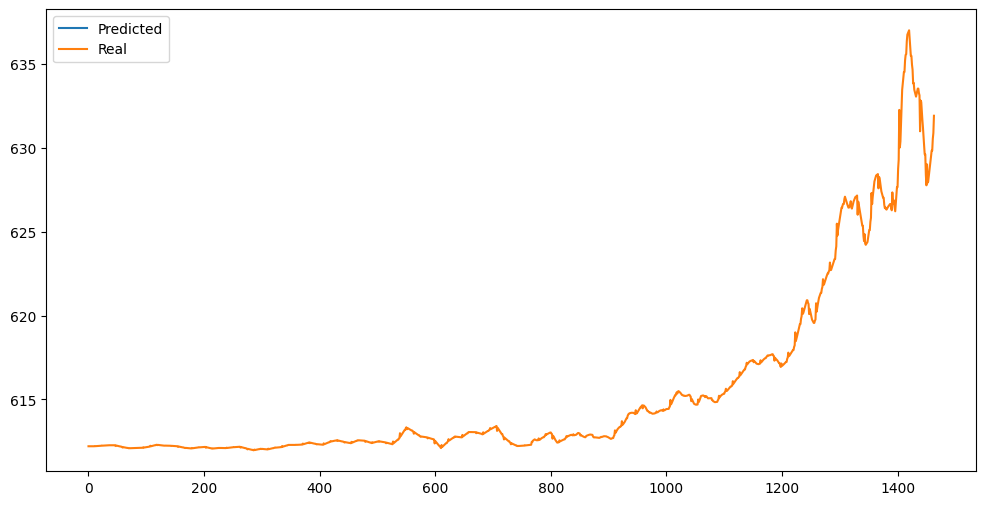

In [607]:
plot_prediction(wg_linear,model)

In [608]:

model = build_linear_model(wg_linear.training_input.shape[1:])
history_linear = model.fit(wg_linear.training_input,wg_linear.training_label,epochs= 120,
                           validation_data=(wg_linear.val_input, wg_linear.val_label),batch_size=BATCH_SIZE,callbacks=[callback])

Epoch 1/120
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3692 - mae: 0.4476 - val_loss: 0.3180 - val_mae: 0.4725
Epoch 2/120
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2429 - mae: 0.3340 - val_loss: 0.1870 - val_mae: 0.3322
Epoch 3/120
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1593 - mae: 0.2638 - val_loss: 0.1251 - val_mae: 0.2533
Epoch 4/120
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1017 - mae: 0.2095 - val_loss: 0.1017 - val_mae: 0.2345
Epoch 5/120
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0636 - mae: 0.1662 - val_loss: 0.0994 - val_mae: 0.2437
Epoch 6/120
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0398 - mae: 0.1330 - val_loss: 0.1062 - val_mae: 0.2628
Epoch 7/120
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0256 - mae: 0.1093 - val_loss: 0.1140 - val_mae: 0.2789
Epoch 8/120
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0176 - mae: 0.0929 - val_loss: 0.1185 - val_mae: 0.2883
Epoch 9/120
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


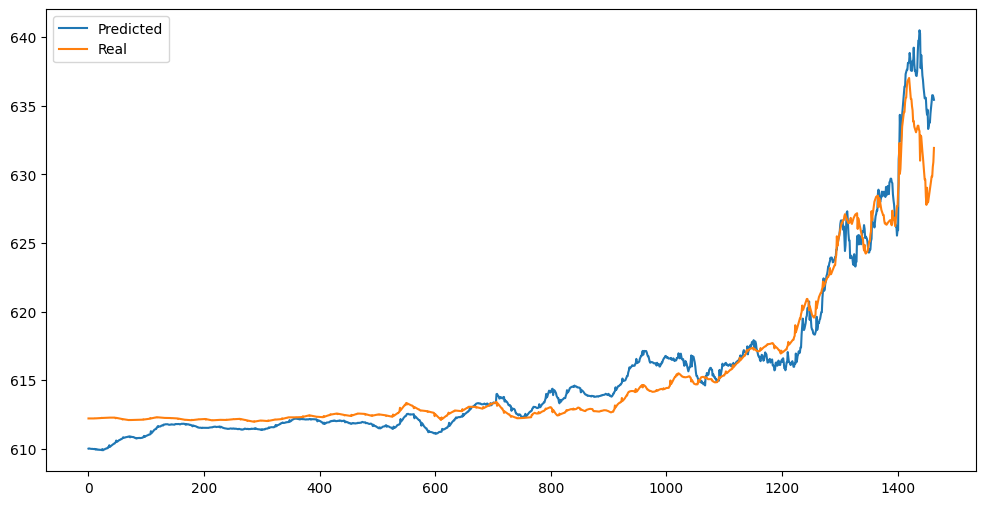

In [609]:
plot_prediction(wg_linear,model)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


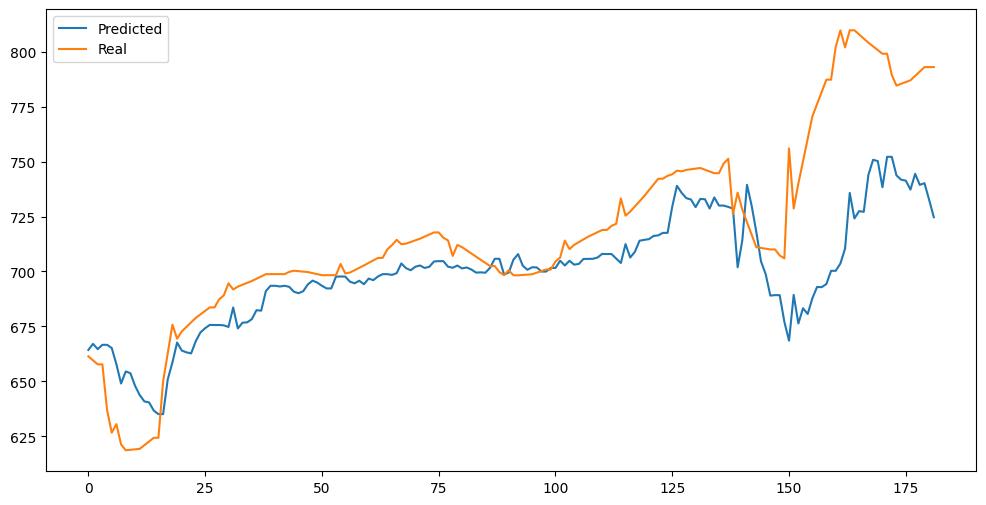

In [610]:
plot_prediction_test(wg_linear,model)

58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 651us/step


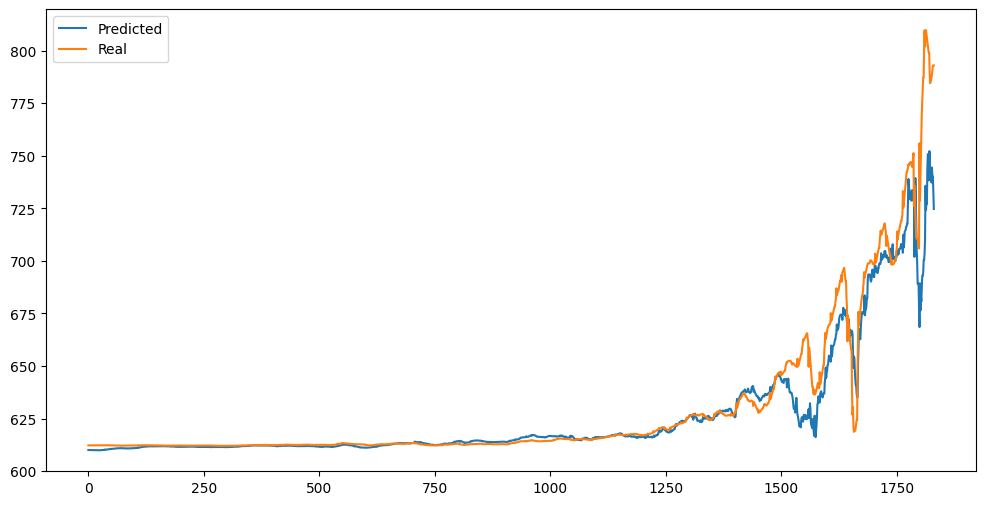

In [611]:
plot_prediction_test_general(wg_linear,model,2)

In [612]:


model = build_linear_model(wg_linear_uni_variable.training_input.reshape(-1, 1).shape[1:])
history_linear_uni = model.fit(wg_linear_uni_variable.training_input.reshape(-1, 1),wg_linear_uni_variable.training_label,
                               epochs= 80 ,validation_data=(wg_linear_uni_variable.val_input, wg_linear_uni_variable.val_label), batch_size= BATCH_SIZE,callbacks=[callback])

Epoch 1/80


122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.1480 - mae: 1.0163 - val_loss: 5.7555 - val_mae: 2.0520
Epoch 2/80
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8445 - mae: 0.8678 - val_loss: 5.7276 - val_mae: 2.0767
Epoch 3/80
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6115 - mae: 0.7398 - val_loss: 5.7020 - val_mae: 2.0979
Epoch 4/80
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4379 - mae: 0.6299 - val_loss: 5.6760 - val_mae: 2.1153
Epoch 5/80
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3127 - mae: 0.5346 - val_loss: 5.6467 - val_mae: 2.1285
Epoch 6/80
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2254 - mae: 0.4535 - val_loss: 5.6115 - val_mae: 2.1375
Epoch 7/80
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1669 - mae: 0.3857 - val_loss: 5.5682 - val_mae: 2.1419
Epoch 8/80
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1293 - mae: 0.3311 - val_loss: 5.5150 - val_mae: 2.1418
Epoch 9/80
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1060 

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


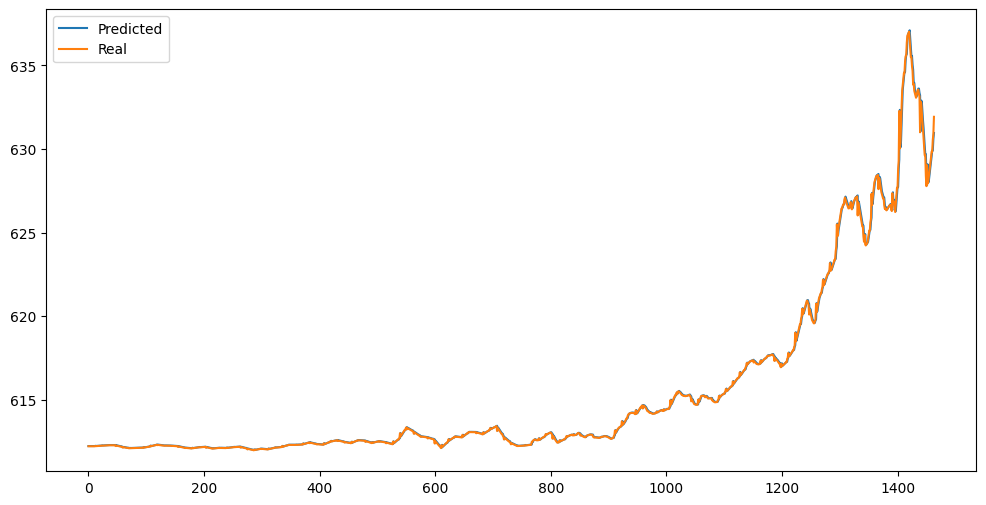

In [613]:
plot_prediction(wg_linear_uni_variable,model)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


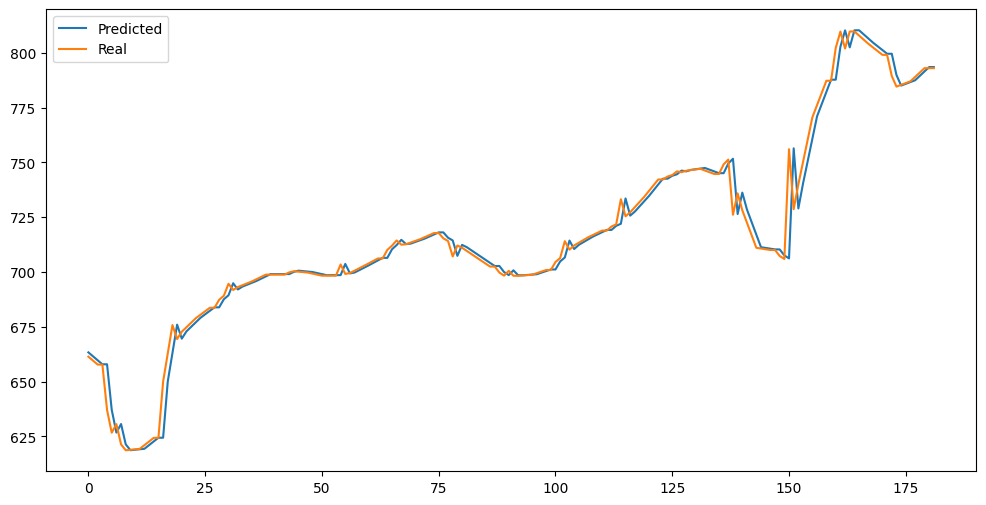

In [614]:
plot_prediction_test(wg_linear_uni_variable,model)

58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 737us/step


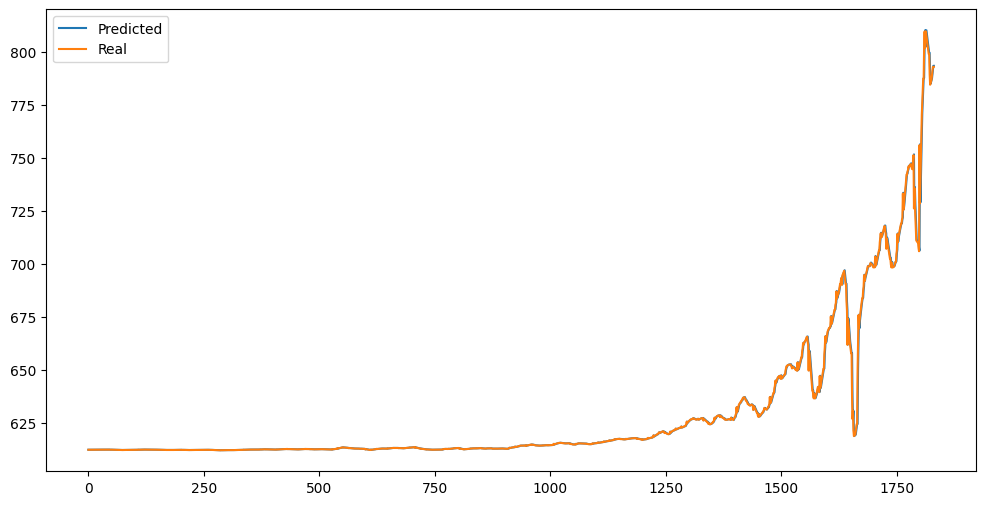

In [615]:
plot_prediction_test_general(wg_linear_uni_variable,model)

In [616]:
model = build_dense_model(wg_linear.training_input.shape[1:])
history_dense = model.fit(wg_linear.training_input,wg_linear.training_label,epochs= EPOCHS,
                          validation_data=(wg_linear.val_input, wg_linear.val_label),batch_size=BATCH_SIZE,callbacks=[callback])

Epoch 1/40
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0414 - mae: 0.1602 - val_loss: 0.4268 - val_mae: 0.5306
Epoch 2/40
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0200 - mae: 0.1129 - val_loss: 0.4448 - val_mae: 0.5571
Epoch 3/40
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0130 - mae: 0.0910 - val_loss: 0.4585 - val_mae: 0.5744
Epoch 4/40
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0089 - mae: 0.0746 - val_loss: 0.4474 - val_mae: 0.5718
Epoch 5/40
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0074 - mae: 0.0685 - val_loss: 0.3919 - val_mae: 0.5364
Epoch 6/40
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0061 - mae: 0.0618 - val_loss: 0.3480 - val_mae: 0.5074
Epoch 7/40
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0054 - mae: 0.0567 - val_loss: 0.3072 - val_mae: 0.4752
Epoch 8/40
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0053 - mae: 0.0563 - val_loss: 0.2309 - val_mae: 0.4086
Epoch 9/40
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - lo

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


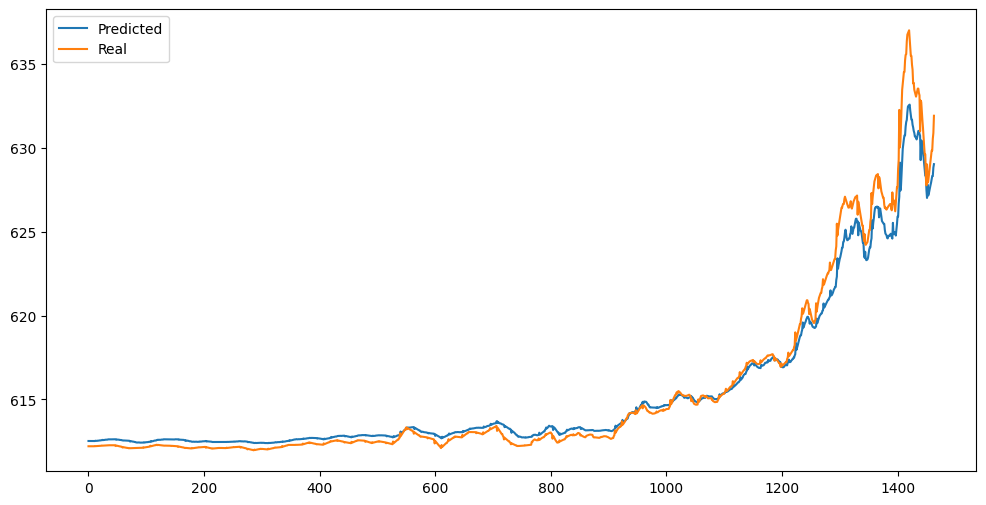

In [617]:
plot_prediction(wg_linear,model)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


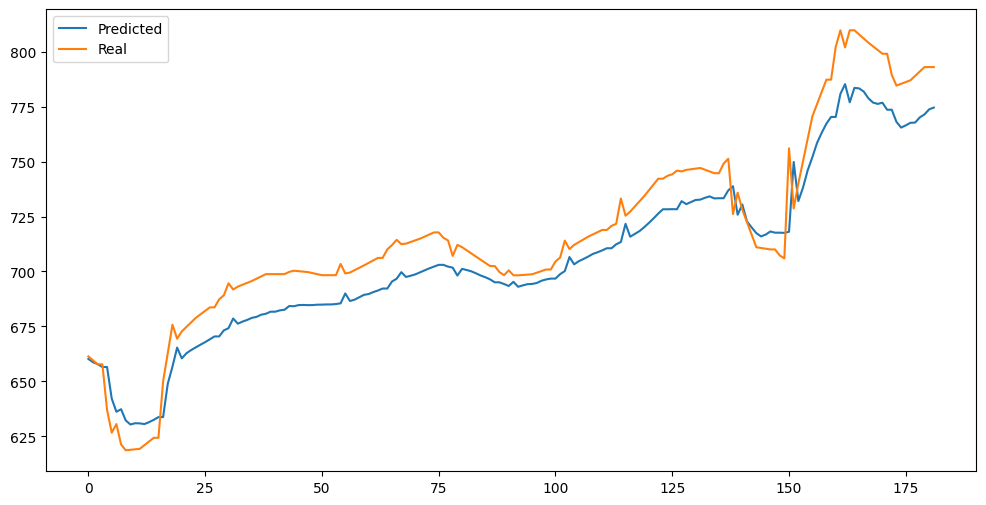

In [618]:
plot_prediction_test(wg_linear,model)

58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 779us/step


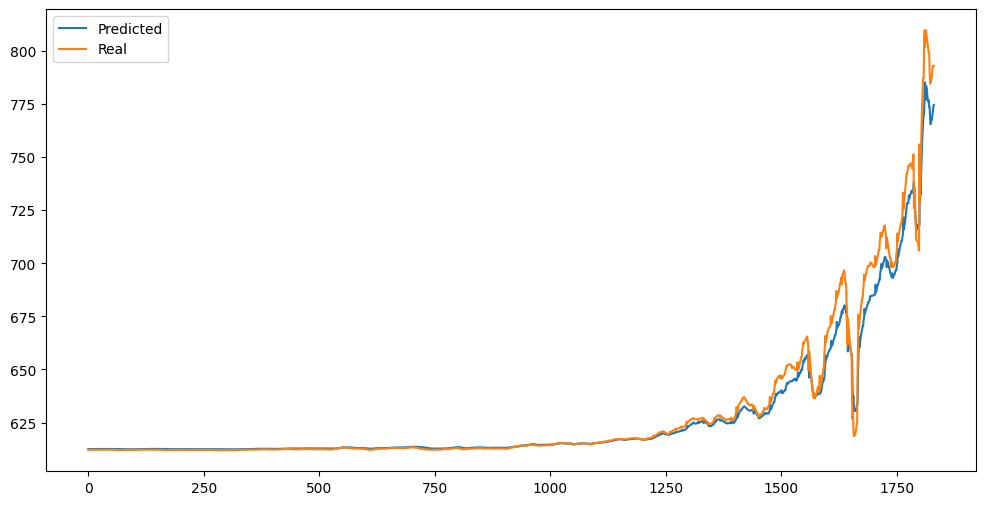

In [619]:
plot_prediction_test_general(wg_linear,model,2)

In [620]:
model = build_lstm_model(wg_lstm.training_input.shape[1:])
history_lstm = model.fit(wg_lstm.training_tf,validation_data=wg_lstm.val_tf,epochs= EPOCHS,callbacks=[callback])

Epoch 1/40
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0389 - mae: 0.1469 - val_loss: 0.4173 - val_mae: 0.5346
Epoch 2/40
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0068 - mae: 0.0658 - val_loss: 0.3616 - val_mae: 0.5015
Epoch 3/40
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0039 - mae: 0.0503 - val_loss: 0.3345 - val_mae: 0.4673
Epoch 4/40
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0065 - mae: 0.0640 - val_loss: 0.3078 - val_mae: 0.4626
Epoch 5/40
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0057 - mae: 0.0584 - val_loss: 0.3345 - val_mae: 0.4712
Epoch 6/40
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0138 - mae: 0.0950 - val_loss: 0.3278 - val_mae: 0.4847
Epoch 7/40
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0117 - mae: 0.0802 - val_loss: 0.4282 - val_mae: 0.5634
Epoch 8/40
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0110 - mae: 0.0865 - val_loss: 0.2820 - val_mae: 0.4447
Epoch 9/40
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0049 - mae:

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


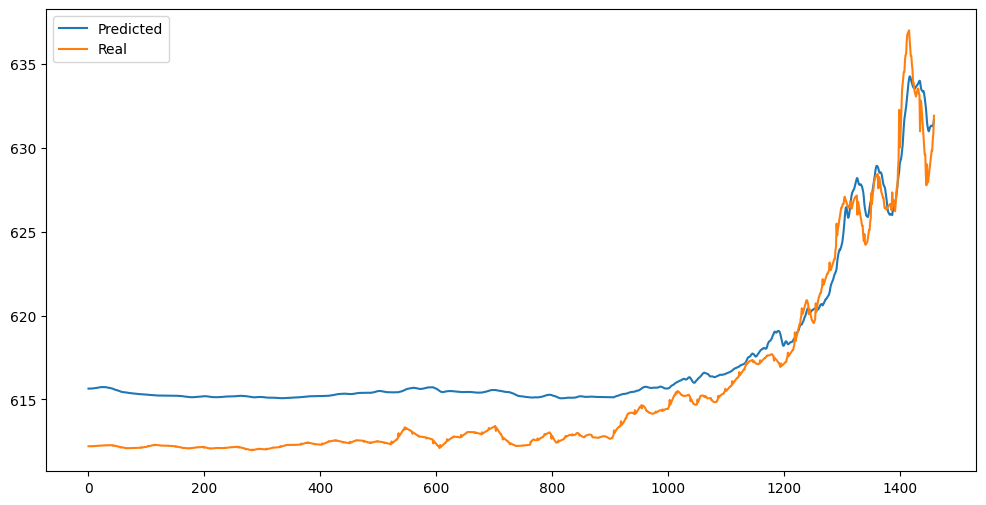

In [621]:
plot_prediction(wg_lstm,model)

58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


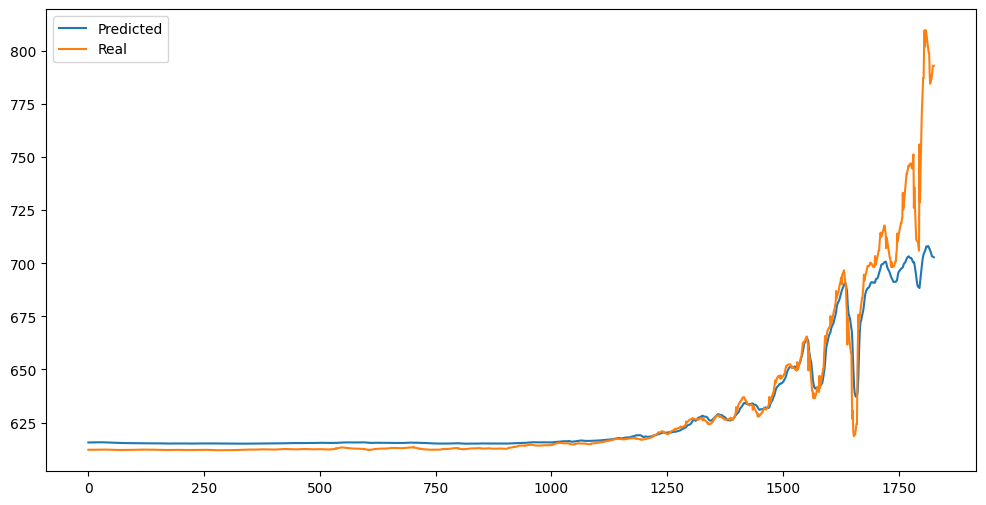

In [622]:
plot_prediction_test_general(wg_lstm,model,2)

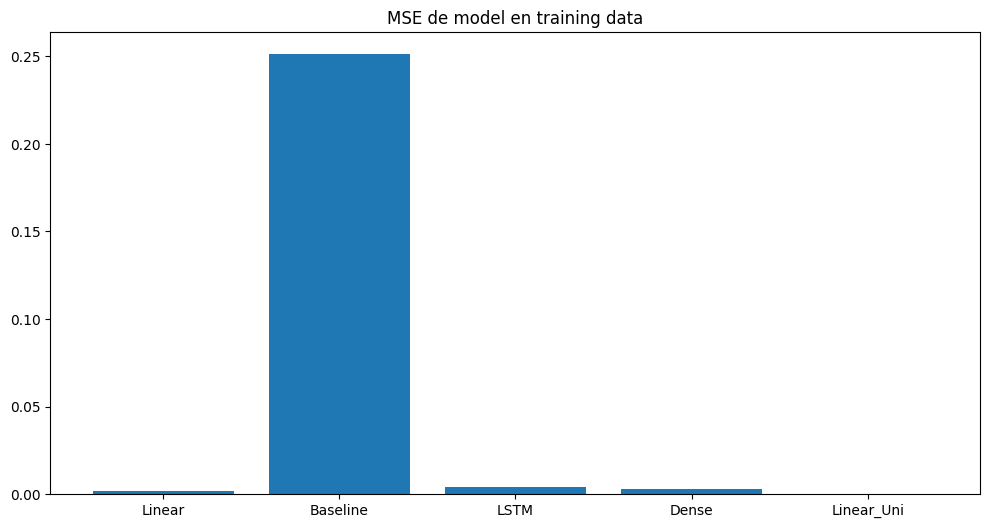

In [623]:
models = {
    "Linear": history_linear,
    "Baseline": history_baseline,
    "LSTM": history_lstm,
    "Dense": history_dense,
    "Linear_Uni": history_linear_uni
}



models_val = {
    "Linear": history_linear,
    "LSTM": history_lstm,
    "Dense": history_dense,
    "Linear_Uni": history_linear_uni
}

plot_bar_metrics("loss", models,"MSE de model en training data")

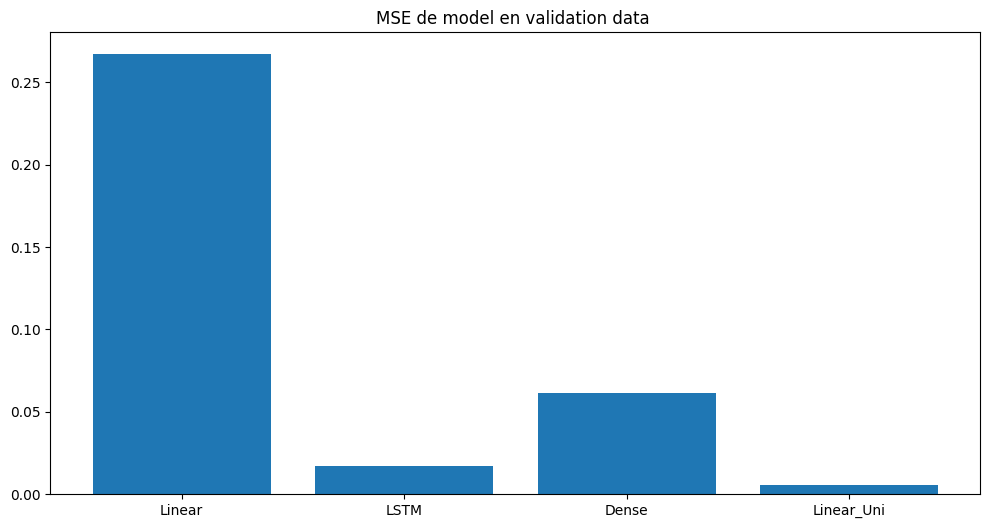

In [624]:
plot_bar_metrics("val_loss", models_val,"MSE de model en validation data ")

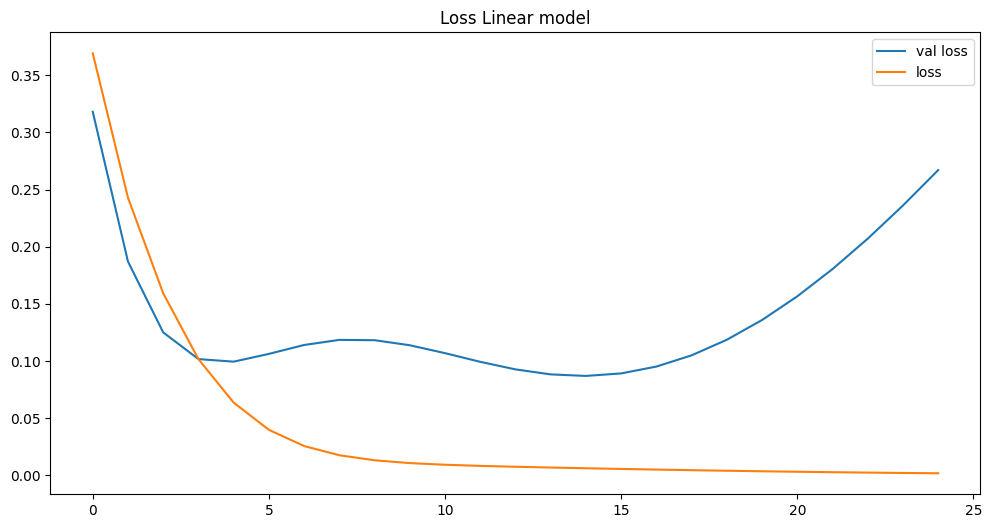

In [625]:
plot_training_validation(models_val["Linear"].history,"loss","Loss Linear model")

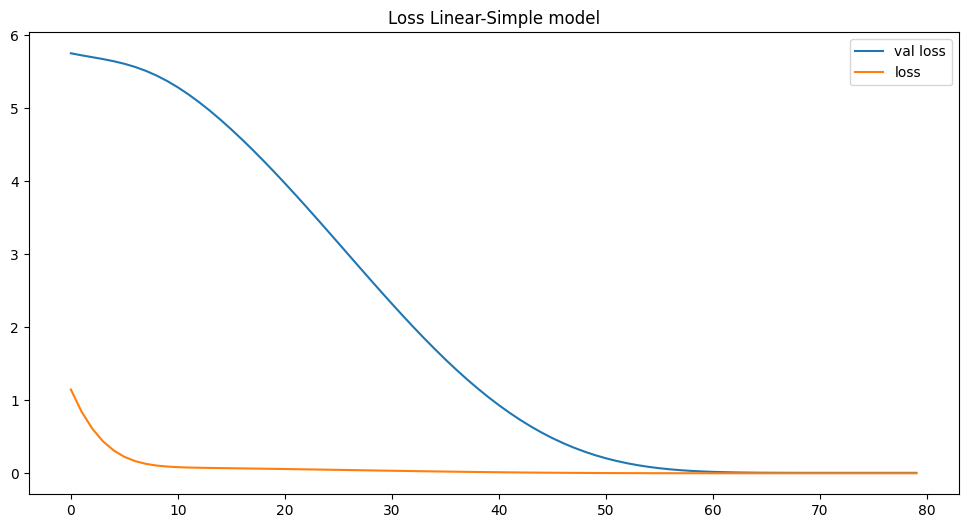

In [626]:
plot_training_validation(models_val["Linear_Uni"].history,"loss","Loss Linear-Simple model")

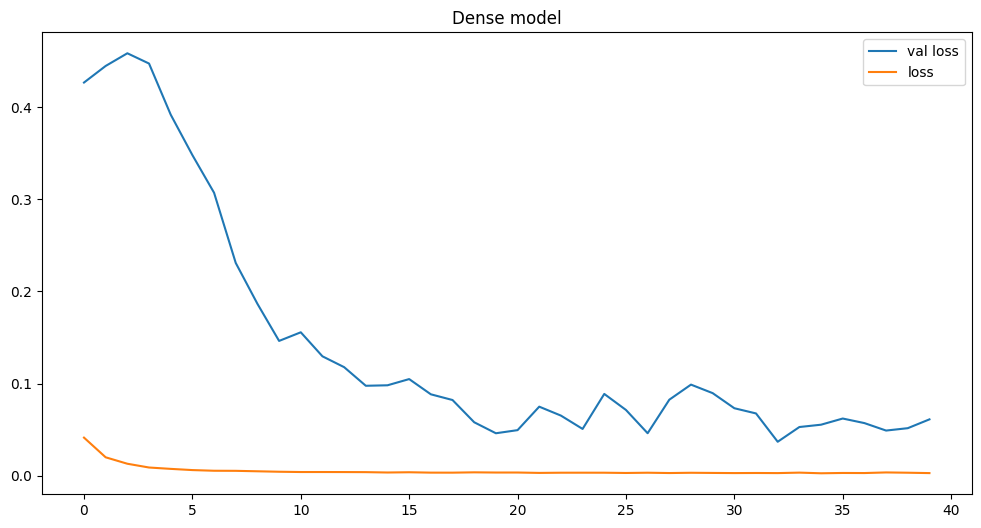

In [627]:
plot_training_validation(models_val["Dense"].history,"loss","Dense model")

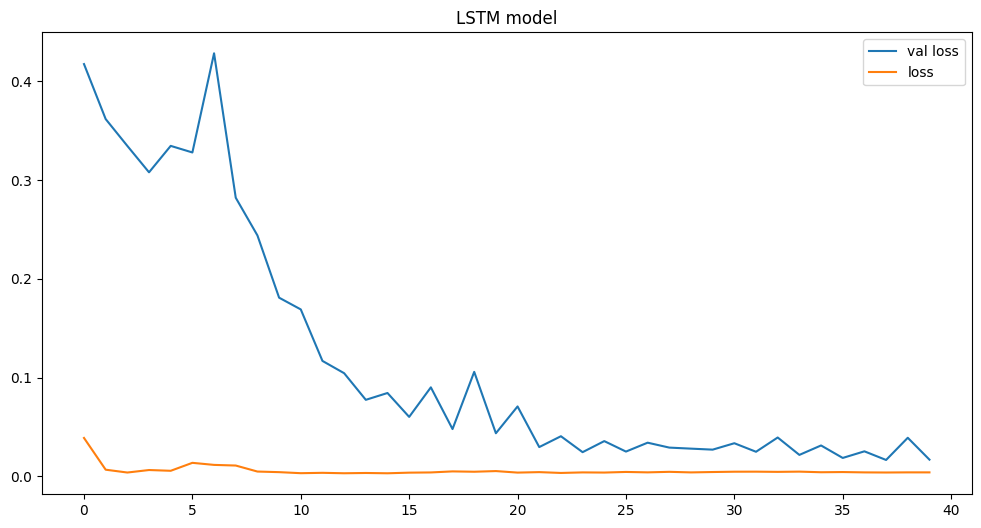

In [628]:
plot_training_validation(models_val["LSTM"].history,"loss","LSTM model")